In [1]:
import xarray as xr
import numpy as np
from scipy.integrate import simpson
from windspharm.xarray import VectorWind

# Constants
Cp = 1004.0
Lv = 2.5e6
g = 9.81

# Load data
ds = xr.open_dataset("ERA5_Temp_SpHum_Geopot_u_v_2022.nc")

# Extract variables
t = ds.t
q = ds.q
z_geopotential = ds.z
u = ds.u
v = ds.v

# Convert geopotential to geopotential height
z = z_geopotential / g  # meters

# Convert pressure from hPa to Pa
pressure = ds.pressure_level * 100.0  # Pa

# Compute MSE
h = Cp * t + Lv * q + g * z  # J/kg

# Compute energy fluxes
uh = u * h  # (m/s) * (J/kg)
vh = v * h  # (m/s) * (J/kg)

# Vertical integration using Simpson's rule
# Integrate over pressure_level dimension
plev_axis = vh.dims.index('pressure_level')

uh_integrated = simpson(uh.values, x=pressure.values, axis=plev_axis)
vh_integrated = simpson(vh.values, x=pressure.values, axis=plev_axis)

# Divide by g
uh_int = uh_integrated / g
vh_int = vh_integrated / g

# Create xarray DataArrays
uh_int = xr.DataArray(
    uh_int,
    coords={'valid_time': ds.valid_time, 'latitude': ds.latitude, 'longitude': ds.longitude},
    dims=('valid_time', 'latitude', 'longitude')
)

vh_int = xr.DataArray(
    vh_int,
    coords={'valid_time': ds.valid_time, 'latitude': ds.latitude, 'longitude': ds.longitude},
    dims=('valid_time', 'latitude', 'longitude')
)



In [2]:
# Compute divergent component for each month
Fphi_div_list = []

for t in range(len(uh_int.valid_time)):
    u_t = uh_int.isel(valid_time=t).fillna(0.0)
    v_t = vh_int.isel(valid_time=t).fillna(0.0)
    
    vw = VectorWind(u_t, v_t)
    u_div, v_div = vw.irrotationalcomponent()
    
    Fphi_div_list.append(v_div)

# Concatenate and assign time
Fphi_div = xr.concat(Fphi_div_list, dim='valid_time')
Fphi_div = Fphi_div.assign_coords(valid_time=uh_int.valid_time)

# Time mean
Fphi_div_mean = Fphi_div.mean(dim='valid_time')

print("Fphi_div_mean range:", Fphi_div_mean.min().values, "to", Fphi_div_mean.max().values)

Fphi_div_mean range: -8240546300.0 to 3666902300.0


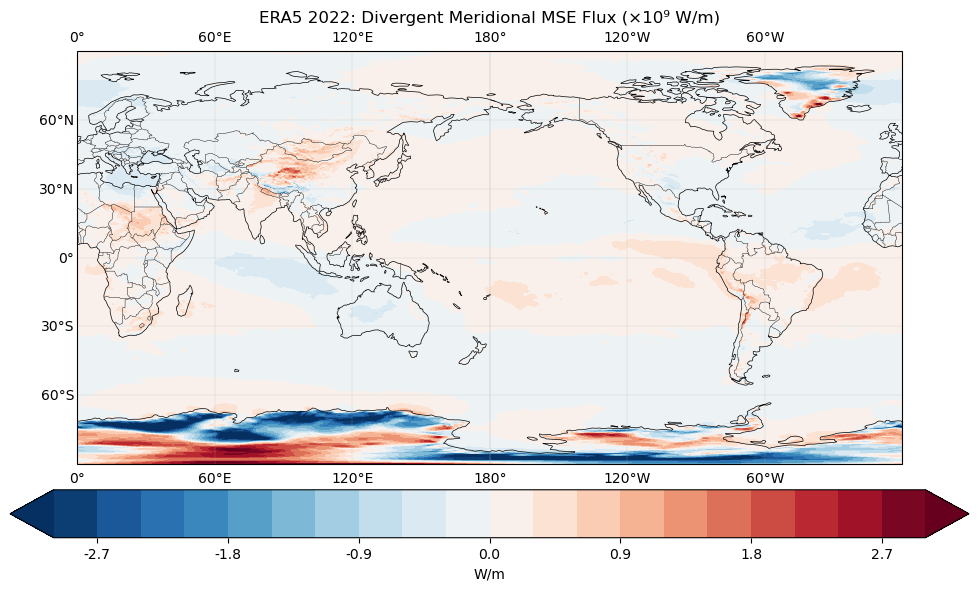

EFE at: 89.63°N
EFE at: 89.33°N
EFE at: 89.15°N
EFE at: 88.82°N
EFE at: 88.64°N
EFE at: 88.31°N
EFE at: 88.15°N
EFE at: 84.85°N
EFE at: 84.66°N
EFE at: 84.37°N
EFE at: 84.12°N
EFE at: 83.78°N
EFE at: 83.74°N
EFE at: 51.10°N
EFE at: 42.83°N
EFE at: 41.84°N
EFE at: 40.01°N
EFE at: 39.15°N
EFE at: 38.03°N
EFE at: 35.51°N
EFE at: 35.10°N
EFE at: 6.92°N
EFE at: -31.66°N
EFE at: -59.39°N
EFE at: -66.32°N
EFE at: -77.14°N
EFE at: -83.39°N
EFE at: -89.34°N


In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Colorbar limits
vmin = -3e9
vmax = 3e9

# Plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree(180)}, figsize=(14, 6))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(Fphi_div_mean.longitude, Fphi_div_mean.latitude, Fphi_div_mean,
                 levels=np.linspace(vmin, vmax, 21), 
                 cmap='RdBu_r', 
                 extend='both',
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(im, ax=ax, shrink=0.7, orientation='horizontal', pad=0.05)
cbar.set_label('W/m')
cbar.formatter = plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}')
cbar.update_ticks()

ax.set_title('ERA5 2022: Divergent Meridional MSE Flux (×10⁹ W/m)')
plt.tight_layout()
plt.savefig('ERA5_Fphi_div_2022.png', dpi=150)
plt.show()

# Find EFE
Fphi_div_zonal = Fphi_div_mean.mean(dim='longitude')
for i in range(len(Fphi_div_zonal.latitude) - 1):
    if Fphi_div_zonal.values[i] * Fphi_div_zonal.values[i+1] < 0:
        lat1 = Fphi_div_zonal.latitude.values[i]
        lat2 = Fphi_div_zonal.latitude.values[i+1]
        val1 = Fphi_div_zonal.values[i]
        val2 = Fphi_div_zonal.values[i+1]
        efe_lat = lat1 - val1 * (lat2 - lat1) / (val2 - val1)
        print(f"EFE at: {efe_lat:.2f}°N")